# Train / Test Split
---
| | |
|---|---|
| **Thesis Title** | A Machine Learning Approach to Solar Irradiance Prediction Using Historical Weather Data |
| **Programme** | B.Sc. Internet Informatics |
| **Institution** | Kaunas University of Technology |
| **Notebook** | 03 — Train / Test Split for SARIMAX and XGBoost |
| **Target Variable** | Global Horizontal Irradiance — GHI (W/m²) |

---
### Notebook Objectives
This notebook prepares model-ready train and test splits from the feature-engineered dataset.
1. Load the engineered dataset and validate its integrity
2. Define a clean calendar-based split: **January–October 2022 (train)** / **November–December 2022 (test)**
3. Prepare a **SARIMAX split** — target series `y` and a curated exogenous feature matrix `X_exog` (no lag/rolling features; SARIMAX models autocorrelation internally via AR/MA terms)
4. Prepare an **XGBoost split** — full feature matrix `X` including all lag, rolling, and interaction features; drop NaN rows introduced by lag computation
5. Validate both splits with visualisations and sanity checks
6. Export all splits to CSV for consumption by downstream modelling notebooks

## Table of Contents
1. [Setup and Data Loading](#setup)
2. [Split Strategy](#strategy)
3. [Define Split Point](#split_point)
4. [SARIMAX Split](#sarimax)
5. [XGBoost Split](#xgboost)
6. [Visualisation of the training and testing](#visual)
7. [Validation Check](#valid)
8. [Export Splits](#export)
9. [Summary](#summary)

---

<a id="setup"></a>
## 1. Setup and Data Loading

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

In [7]:
df = pd.read_csv('../data/df_engineered.csv', index_col='Date Time', parse_dates=True)
df = df.sort_index()

In [8]:
df.shape

(8760, 80)

In [9]:
df.head(3)

,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Relative Humidity,Wind Direction,Wind Speed,DHI,DNI,...,cloud_clearsky,wind_x_precip_water,cos_zenith_x_clearsky,GHI_diff_1h,GHI_diff_24h,season_Autumn,season_Spring,season_Summer,season_Winter,season_ordinal
Date Time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:30:00,4.9,0,0,0,1,69.27,172,3.4,0,0,...,0,4.76,-0.0,NaN,NaN,False,False,False,True,0
2022-01-01 01:30:00,5.2,0,0,0,4,57.26,183,1.6,0,0,...,0,0.80,-0.0,0.0,NaN,False,False,False,True,0
2022-01-01 02:30:00,5.3,0,0,0,0,55.49,184,1.5,0,0,...,0,0.75,-0.0,0.0,NaN,False,False,False,True,0


In [11]:
print(f'Date range     : {df.index.min()}  →  {df.index.max()}')
print(f'Missing values : {df.isnull().sum().sum()}')

Date range     : 2022-01-01 00:30:00  →  2022-12-31 23:30:00
Missing values : 128


---
<a id="strategy"></a>
## 2. Split Strategy

Time series data must **never** be split randomly — doing so would leak future information into the training set and produce optimistically biased evaluation metrics.

A strict **temporal hold-out** is used instead:

| Set | Period | Approx. rows | Rationale |
|---|---|---|---|
| Train | Jan – Oct 2022 | ~7,344 hrs | Covers all four seasons; gives models sufficient seasonal cycles |
| Test  | Nov – Dec 2022 | ~1,464 hrs | Two unseen winter months; low-irradiance regime tests generalisation |

**Why November–December as the test set?**  
Winter months represent the hardest forecasting regime for solar irradiance — low sun elevation, short days, higher cloud cover, and rapid weather changes. Evaluating on this period gives a conservative, realistic estimate of model performance.

### Feature sets per model

| Feature group | SARIMAX | XGBoost |
|---|---|---|
| Calendar (raw) | No — redundant with cyclic encoding | Yes |
| Cyclic encoding | Yes | Yes |
| Solar physics (Kt, zenith) | Yes | Yes |
| Lag features | No — SARIMAX handles autocorrelation via AR terms | Yes |
| Rolling statistics | No | Yes |
| Interaction / ratio features | Selected subset | Yes |
| Season encoding | No | Yes |
| Meteorological predictors | Selected subset | Yes |

---
<a id="split_point"></a>
## 3. Define Split Point

In [12]:
TRAIN_END = '2022-10-31 23:00:00'
TEST_START = '2022-11-01 00:00:00'

df_train_full = df.loc[:TRAIN_END].copy()
df_test_full  = df.loc[TEST_START:].copy()

print('Split summary:')
print(f'  Train : {df_train_full.index.min().date()}  →  {df_train_full.index.max().date()}'
      f'  ({len(df_train_full):,} rows, {len(df_train_full)/len(df)*100:.1f}%)')
print(f'  Test  : {df_test_full.index.min().date()}  →  {df_test_full.index.max().date()}'
      f'  ({len(df_test_full):,} rows, {len(df_test_full)/len(df)*100:.1f}%)')
print(f'  Total : {len(df):,} rows')

Split summary:
  Train : 2022-01-01  →  2022-10-31  (7,295 rows, 83.3%)
  Test  : 2022-11-01  →  2022-12-31  (1,464 rows, 16.7%)
  Total : 8,760 rows


---
<a id="sarimax"></a>
## 4. SARIMAX Split

SARIMAX explicitly models the autocorrelation structure of the target series through its AR, I, and MA components. Including lag or rolling features as exogenous regressors would therefore introduce **redundant and collinear** signals, destabilising parameter estimation.

The exogenous feature set for SARIMAX is restricted to:
- **Cyclic time encodings** — capture diurnal and seasonal periodicity not modelled by the SARIMA terms
- **Solar physics features** — Kₜ, sin(zenith), diffuse fraction; physically grounded and non-redundant
- **Selected meteorological predictors** — temperature, humidity, wind speed, precipitable water, cloud type
- **Interaction features** — cos_zenith × clearsky_GHI and temperature × humidity

Highly collinear pairs (e.g. `Clearsky GHI` with `cos_zenith_x_clearsky`) are excluded to ensure stable coefficient estimation.

In [63]:
SARIMAX_EXOG_FEATURES = [
    # Cyclic time encodings
    'hour_sin',  'hour_cos',
    'day_of_year_sin', 'day_of_year_cos',
   
    # Solar physics
    'kt_ghi',
    'sin_zenith',
    'diffuse_fraction',

    # Meteorological predictors
    'Temperature',
    'Relative Humidity',
    'Wind Speed',
    'Precipitable Water',
    'Cloud Type',

    # Interaction features
    'cos_zenith_x_clearsky',
    'temp_x_humidity',

   ]

# Verify all features exist in the dataframe
missing = [f for f in SARIMAX_EXOG_FEATURES if f not in df.columns]
if missing:
    raise ValueError(f'Missing SARIMAX features: {missing}')
print(f'SARIMAX exogenous feature count: {len(SARIMAX_EXOG_FEATURES)}')

SARIMAX exogenous feature count: 14


In [64]:
# Target series
y_train_sarimax = df_train_full['GHI']
y_test_sarimax  = df_test_full['GHI']

# Exogenous feature matrices
X_train_sarimax = df_train_full[SARIMAX_EXOG_FEATURES]
X_test_sarimax  = df_test_full[SARIMAX_EXOG_FEATURES]

# Sanity check: no NaNs expected in SARIMAX features (no lag/rolling columns)
assert X_train_sarimax.isnull().sum().sum() == 0, 'NaNs found in SARIMAX train features'
assert X_test_sarimax.isnull().sum().sum()  == 0, 'NaNs found in SARIMAX test features'

print('SARIMAX split:')
print(f'  y_train_sarimax : {y_train_sarimax.shape}')
print(f'  X_train_sarimax : {X_train_sarimax.shape}')
print(f'  y_test_sarimax  : {y_test_sarimax.shape}')
print(f'  X_test_sarimax  : {X_test_sarimax.shape}')

SARIMAX split:
  y_train_sarimax : (7295,)
  X_train_sarimax : (7295, 14)
  y_test_sarimax  : (1464,)
  X_test_sarimax  : (1464, 14)


---
<a id="xgboost"></a>
## 5. XGBoost Split

XGBoost is a non-parametric tree-based model with no built-in temporal structure. All engineered features — including lag, rolling, and interaction terms — are included explicitly to give the model access to recent history and local temporal dynamics.

### NaN handling
Lag and rolling features produce `NaN` values in the first rows of the dataset (up to 24 rows from the 24-hour lag). These rows are **dropped** rather than filled because:
- They represent fewer than 0.3% of the training set
- All affected rows fall in early January (well within the training window)
- Filling with 0 would be semantically incorrect — `GHI = 0` is a valid physical value (nighttime), and imputing lag features with 0 would imply the preceding hours had zero irradiance

In [65]:
EXCLUDE_COLS = [
    'GHI',          # target value
    'Season',       
    'DHI',
    'DNI',
    'Clearsky DHI', 
    'Clearsky DNI',
]

XGBOOST_FEATURES = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in EXCLUDE_COLS
]

print(f'XGBoost feature count (before NaN drop): {len(XGBOOST_FEATURES)}')

XGBoost feature count (before NaN drop): 70


In [66]:
X_train_xgb_raw = df_train_full[XGBOOST_FEATURES]
y_train_xgb_raw = df_train_full['GHI']
X_test_xgb      = df_test_full[XGBOOST_FEATURES]
y_test_xgb      = df_test_full['GHI']

# Report NaNs before dropping
nan_rows_train = X_train_xgb_raw.isnull().any(axis=1).sum()
nan_rows_test  = X_test_xgb.isnull().any(axis=1).sum()
print(f'NaN rows in train (before drop): {nan_rows_train}')
print(f'NaN rows in test               : {nan_rows_test}')

# Drop NaN rows from training set only
valid_train_idx  = X_train_xgb_raw.dropna().index
X_train_xgb      = X_train_xgb_raw.loc[valid_train_idx]
y_train_xgb      = y_train_xgb_raw.loc[valid_train_idx]

print(f'\nXGBoost split (after NaN drop):')
print(f'  X_train_xgb : {X_train_xgb.shape}  (dropped {nan_rows_train} rows)')
print(f'  y_train_xgb : {y_train_xgb.shape}')
print(f'  X_test_xgb  : {X_test_xgb.shape}')
print(f'  y_test_xgb  : {y_test_xgb.shape}')

NaN rows in train (before drop): 24
NaN rows in test               : 0

XGBoost split (after NaN drop):
  X_train_xgb : (7271, 70)  (dropped 24 rows)
  y_train_xgb : (7271,)
  X_test_xgb  : (1464, 70)
  y_test_xgb  : (1464,)


In [67]:
assert X_train_xgb.isnull().sum().sum() == 0, 'Residual NaNs in XGBoost train features'
assert X_test_xgb.isnull().sum().sum()  == 0, 'Residual NaNs in XGBoost test features'
print('NaN check passed for both XGBoost splits.')

NaN check passed for both XGBoost splits.


---
<a id="visual"></a>
## 6. Visualisation of the training and testing 

### 6.1 Train/test timeline

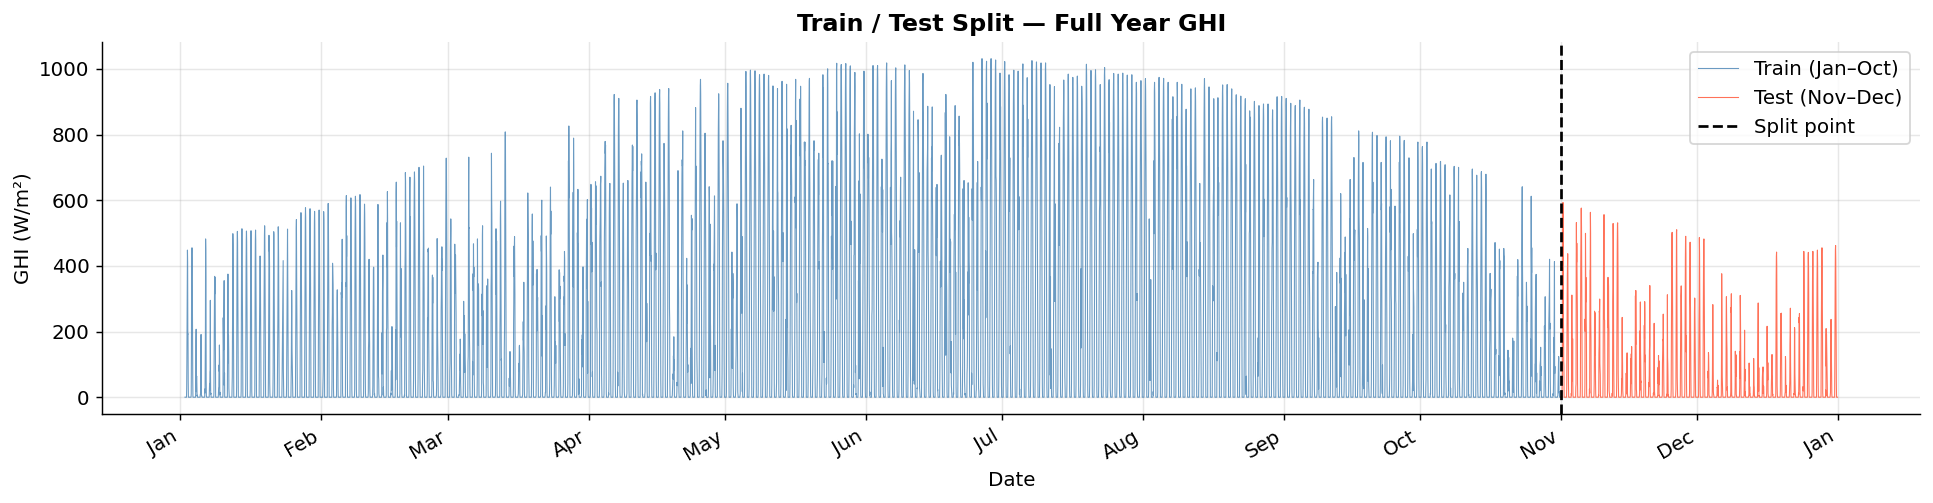

In [68]:
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(y_train_xgb.index, y_train_xgb.values,
        lw=0.6, color='steelblue', alpha=0.8, label='Train (Jan–Oct)')
ax.plot(y_test_xgb.index, y_test_xgb.values,
        lw=0.6, color='tomato', alpha=0.9, label='Test (Nov–Dec)')
ax.axvline(pd.Timestamp(TEST_START), color='black',
           linestyle='--', lw=1.5, label='Split point')

ax.set_xlabel('Date')
ax.set_ylabel('GHI (W/m²)')
ax.set_title('Train / Test Split — Full Year GHI', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('../outputs/figures/plot_train_test_split.png', bbox_inches='tight')
plt.show()

### 6.2 Monthly mean GHI — confirms no data leakage at split boundary

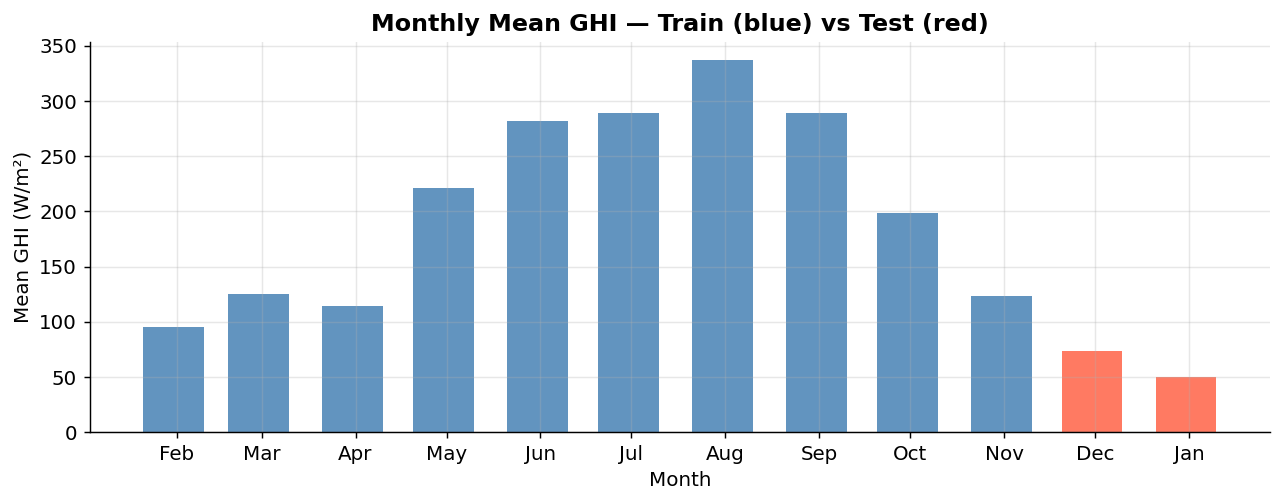

In [69]:
monthly_train = y_train_xgb.resample('ME').mean()
monthly_test  = y_test_xgb.resample('ME').mean()
monthly_all   = pd.concat([monthly_train, monthly_test])
colors        = ['steelblue'] * len(monthly_train) + ['tomato'] * len(monthly_test)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_all.index, monthly_all.values, width=20, color=colors, alpha=0.85)
ax.set_xlabel('Month')
ax.set_ylabel('Mean GHI (W/m²)')
ax.set_title('Monthly Mean GHI — Train (blue) vs Test (red)', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.savefig('../outputs/figures/plot_monthly_mean_split.png', bbox_inches='tight')
plt.show()

### 6.3 GHI distribution: train vs test

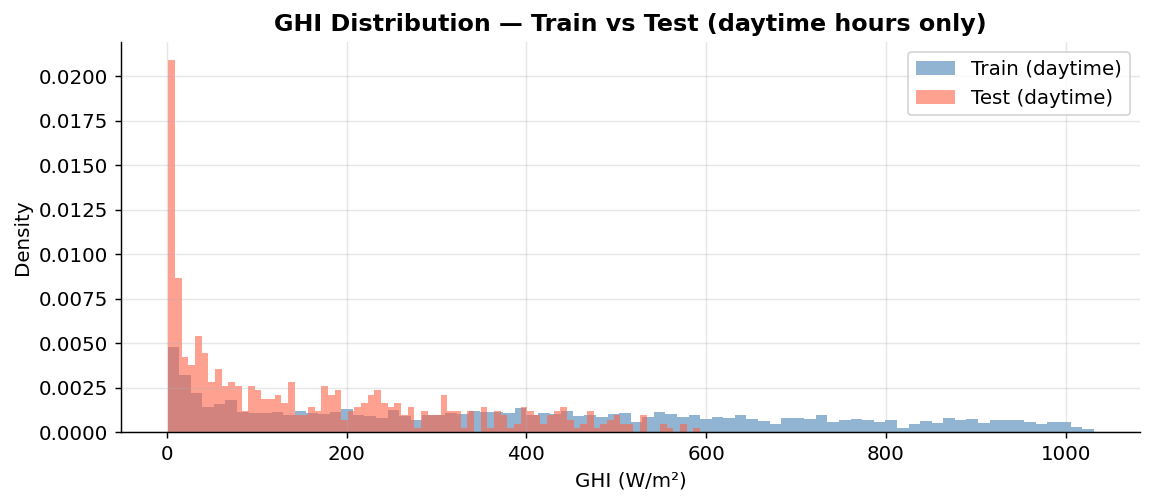


GHI descriptive statistics:
         Train     Test
count  7271.00  1464.00
mean    208.47    61.78
std     292.88   122.62
min       0.00     0.00
25%       0.00     0.00
50%       8.00     0.00
75%     389.00    52.00
max    1031.00   593.00


In [70]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_train_xgb[y_train_xgb > 0], bins=80,
        color='steelblue', alpha=0.6, density=True, label='Train (daytime)')
ax.hist(y_test_xgb[y_test_xgb > 0],  bins=80,
        color='tomato',    alpha=0.6, density=True, label='Test (daytime)')
ax.set_xlabel('GHI (W/m²)')
ax.set_ylabel('Density')
ax.set_title('GHI Distribution — Train vs Test (daytime hours only)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/plot_ghi_distribution_split.png', bbox_inches='tight')
plt.show()

print('\nGHI descriptive statistics:')
stats = pd.DataFrame({
    'Train': y_train_xgb.describe(),
    'Test' : y_test_xgb.describe()
}).round(2)
print(stats.to_string())

---
<a id=valid></a>
## 7. Validation Check


In [71]:
corr_sarimax = X_train_sarimax.corr().abs()
upper        = corr_sarimax.where(np.triu(np.ones_like(corr_sarimax, dtype=bool), k=1))
high_corr    = upper.stack()[upper.stack() > 0.85]

if len(high_corr) > 0:
    print('WARNING — Highly correlated SARIMAX feature pairs (|r| > 0.85):')
    print(high_corr.round(3).to_string())
    print('Consider dropping one feature from each pair before fitting SARIMAX.')
else:
    print('Collinearity check passed: no SARIMAX feature pairs with |r| > 0.85.')

Collinearity check passed: no SARIMAX feature pairs with |r| > 0.85.


---
<a id="export"></a>
## 8. Export Splits

In [72]:
# SARIMAX splits
X_train_sarimax.to_csv('../data/sarimax_X_train.csv')
X_test_sarimax.to_csv('../data/sarimax_X_test.csv')
y_train_sarimax.to_csv('../data/sarimax_y_train.csv', header=True)
y_test_sarimax.to_csv('../data/sarimax_y_test.csv',   header=True)

# XGBoost splits
X_train_xgb.to_csv('../data/xgb_X_train.csv')
X_test_xgb.to_csv('../data/xgb_X_test.csv')
y_train_xgb.to_csv('../data/xgb_y_train.csv', header=True)
y_test_xgb.to_csv('../data/xgb_y_test.csv',   header=True)

# Feature name lists (useful for downstream notebooks)
pd.Series(SARIMAX_EXOG_FEATURES).to_csv('../data/sarimax_feature_names.csv', index=False, header=['feature'])
pd.Series(XGBOOST_FEATURES).to_csv('../data/xgb_feature_names.csv',          index=False, header=['feature'])

print('All splits exported:')
export_files = [
    'sarimax_X_train.csv', 'sarimax_X_test.csv',
    'sarimax_y_train.csv', 'sarimax_y_test.csv',
    'xgb_X_train.csv',     'xgb_X_test.csv',
    'xgb_y_train.csv',     'xgb_y_test.csv',
    'sarimax_feature_names.csv', 'xgb_feature_names.csv',
]
for f in export_files:
    print(f'  ../data/{f}')

All splits exported:
  ../data/sarimax_X_train.csv
  ../data/sarimax_X_test.csv
  ../data/sarimax_y_train.csv
  ../data/sarimax_y_test.csv
  ../data/xgb_X_train.csv
  ../data/xgb_X_test.csv
  ../data/xgb_y_train.csv
  ../data/xgb_y_test.csv
  ../data/sarimax_feature_names.csv
  ../data/xgb_feature_names.csv


---
<a id="summary"></a>
## 9. Summary

| | SARIMAX | XGBoost |
|---|---|---|
| **Train period** | Jan – Oct 2022 | Jan – Oct 2022 |
| **Test period** | Nov – Dec 2022 | Nov – Dec 2022 |
| **Train rows** | ~7,344 | ~7,320 (24 dropped) |
| **Test rows** | ~1,464 | ~1,464 |
| **Feature count** | 14 exog features | All engineered features |
| **Lag/rolling features** | No | Yes |
| **NaN handling** | N/A (none present) | Drop first 24 rows |
| **Season reference** | No | All season dummies included |